In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\User\OneDrive\Desktop\Python-master\Python-master\Superstore.csv', encoding='latin1')

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [13]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [14]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [15]:
#Filter rows where sales is > 1000


In [16]:
# Filter rows with loss

In [17]:
#Calculate total sales per category


In [18]:
# Total profit per region
df.groupby('Region')['Profit'].sum()

,Profit
Region,
Central,39706.3625
East,91522.7800
South,46749.4303
West,108418.4489


In [19]:
#highest sale (top 10)
#biggest losses (top 10)
# plot histogram of sales
# plot bar chart of sales by category
#line plot of yearly sales

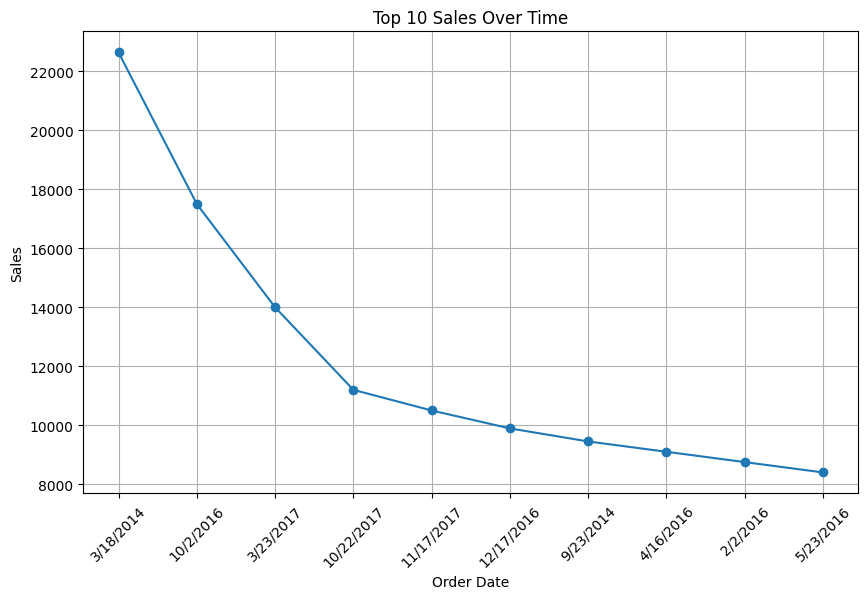

In [12]:
#highest sale (top 10) plot line plot of yearly sales
top_sales = df.sort_values(by='Sales', ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.plot(top_sales['Order Date'], top_sales['Sales'], marker='o')
plt.title('Top 10 Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

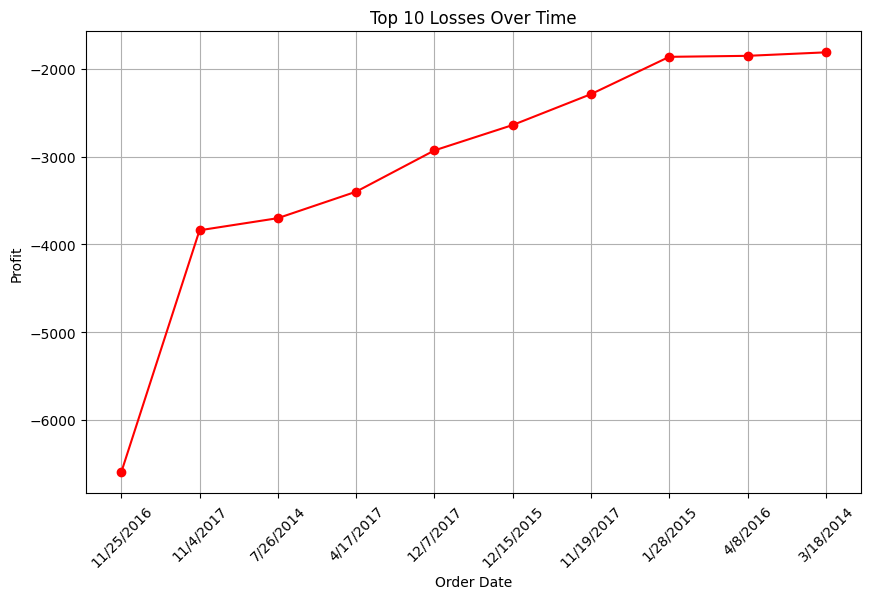

In [13]:
#biggest losses (top 10) plot line plot of yearly losses
top_losses = df.sort_values(by='Profit', ascending=True).head(10)
plt.figure(figsize=(10, 6))
plt.plot(top_losses['Order Date'], top_losses['Profit'], marker='o', color='red')
plt.title('Top 10 Losses Over Time')
plt.xlabel('Order Date')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid()
plt.show()

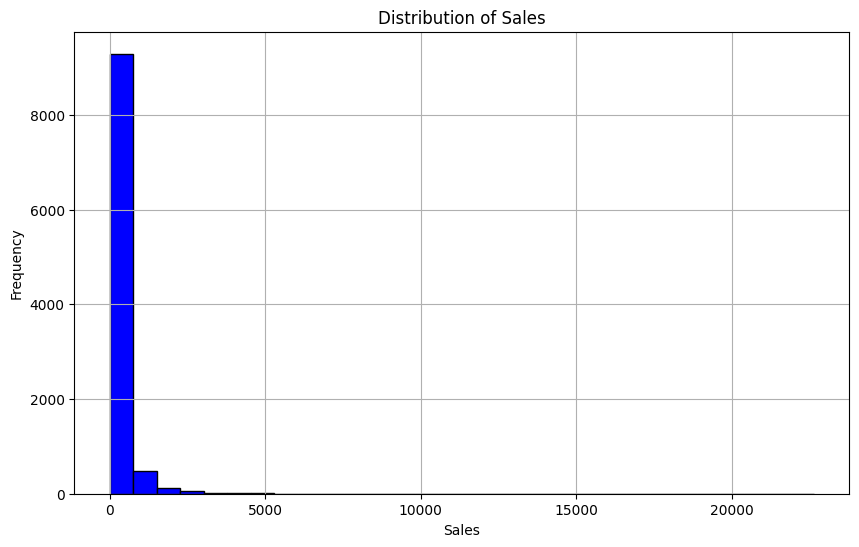

In [9]:
# plot histogram of sales
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid()
plt.show()

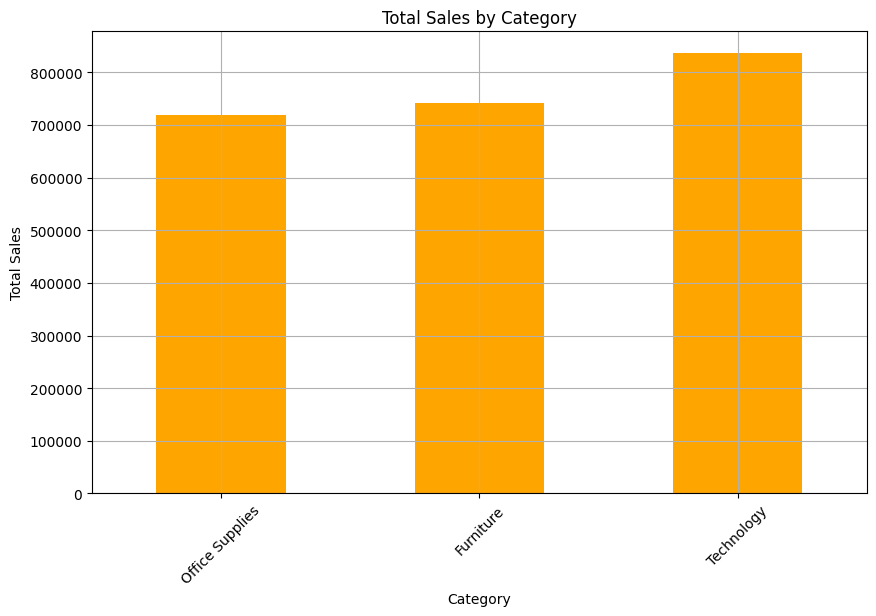

In [10]:
#plot bar chart of sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color='orange')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

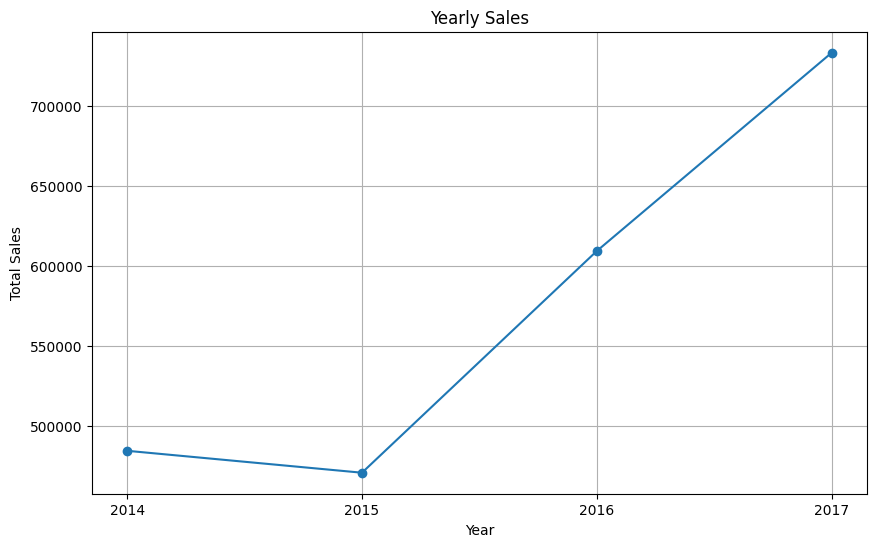

In [14]:
#Line plot of yearly sales
# Ensure Year column exists
df['Year'] = pd.to_datetime(df['Order Date']).dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.figure(figsize=(10, 6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_sales.index)
plt.grid()
plt.show()